In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv("customer_churn.csv")

In [4]:
df.head()

,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn
0,C00001,6,64,1540,One year,Credit Card,No,1,0
1,C00002,21,113,1753,Month-to-month,Electronic Check,Yes,1,0
2,C00003,27,31,1455,Two year,Credit Card,No,1,0
3,C00004,53,29,7150,Month-to-month,Electronic Check,No,1,0
4,C00005,16,185,1023,One year,Electronic Check,No,1,0


In [5]:
df.tail()

,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn
495,C00496,50,128,6970,Month-to-month,Credit Card,Yes,1,0
496,C00497,2,49,5917,Two year,Bank Transfer,No,1,0
497,C00498,46,198,2158,Month-to-month,Bank Transfer,No,0,0
498,C00499,1,185,5755,Two year,Credit Card,Yes,1,1
499,C00500,27,181,4292,Month-to-month,Bank Transfer,No,1,0


In [6]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 500
Columns: 9


In [9]:
df.columns

Index(['CustomerID', 'Tenure', 'MonthlyCharges', 'TotalCharges', 'Contract',
       'PaymentMethod', 'PaperlessBilling', 'SeniorCitizen', 'Churn'],
      dtype='object')

In [10]:
df.info

<bound method DataFrame.info of     CustomerID  Tenure  MonthlyCharges  TotalCharges        Contract  \
0       C00001       6              64          1540        One year   
1       C00002      21             113          1753  Month-to-month   
2       C00003      27              31          1455        Two year   
3       C00004      53              29          7150  Month-to-month   
4       C00005      16             185          1023        One year   
..         ...     ...             ...           ...             ...   
495     C00496      50             128          6970  Month-to-month   
496     C00497       2              49          5917        Two year   
497     C00498      46             198          2158  Month-to-month   
498     C00499       1             185          5755        Two year   
499     C00500      27             181          4292  Month-to-month   

        PaymentMethod PaperlessBilling  SeniorCitizen  Churn  
0         Credit Card               No              1      0  
1    Electronic Check              Yes              1      0  
2         Credit Card               No              1      0  
3    Electronic Check               No              1      0  
4    Electronic Check               No              1      0  
..                ...              ...            ...    ...  
495       Credit Card              Yes              1      0  
496     Bank Transfer               No              1      0  
497     Bank Transfer               No              0      0  
498       Credit Card              Yes              1      1  
499     Bank Transfer               No              1      0  

[500 rows x 9 columns]>

In [12]:
df.isnull().sum()

,0
CustomerID,0
Tenure,0
MonthlyCharges,0
TotalCharges,0
Contract,0
PaymentMethod,0
PaperlessBilling,0
SeniorCitizen,0
Churn,0


In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df = df.drop_duplicates()

In [15]:
df.describe()

,Tenure,MonthlyCharges,TotalCharges,SeniorCitizen,Churn
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,36.532000,113.636000,4237.882000,0.498000,0.106000
std,20.667057,51.799903,2260.619837,0.500497,0.308146
min,1.000000,20.000000,159.000000,0.000000,0.000000
25%,19.000000,67.000000,2237.250000,0.000000,0.000000
50%,37.000000,115.000000,4182.500000,0.000000,0.000000
75%,54.000000,158.000000,6266.750000,1.000000,0.000000
max,71.000000,199.000000,7992.000000,1.000000,1.000000


In [16]:
df.describe(include='object')

,CustomerID,Contract,PaymentMethod,PaperlessBilling
count,500,500,500,500
unique,500,3,3,2
top,C00500,One year,Credit Card,No
freq,1,186,178,257


In [17]:
df.to_csv("cleaned_data.csv", index=False)

In [18]:
df.dtypes

,0
CustomerID,object
Tenure,int64
MonthlyCharges,int64
TotalCharges,int64
Contract,object
PaymentMethod,object
PaperlessBilling,object
SeniorCitizen,int64
Churn,int64


In [22]:
encoder = LabelEncoder()
for column in df.columns:
  if df[column].dtype == 'object':
      df[column] = encoder.fit_transform(df[column])

In [23]:
df.head()

,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn
0,0,6,64,1540,1,1,0,1,0
1,1,21,113,1753,0,2,1,1,0
2,2,27,31,1455,2,1,0,1,0
3,3,53,29,7150,0,2,0,1,0
4,4,16,185,1023,1,2,0,1,0


In [24]:
df.corr()

,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn
CustomerID,1.000000,-0.008709,-0.001773,0.038596,-0.050747,0.088634,0.019032,-0.009797,0.005784
Tenure,-0.008709,1.000000,-0.059655,-0.005677,-0.041916,-0.015105,0.023786,-0.040001,-0.509208
MonthlyCharges,-0.001773,-0.059655,1.000000,-0.042280,0.010046,0.021021,0.012562,-0.105695,0.107381
TotalCharges,0.038596,-0.005677,-0.042280,1.000000,0.049869,0.004987,0.013677,0.016360,0.004250
Contract,-0.050747,-0.041916,0.010046,0.049869,1.000000,0.003807,0.063944,-0.000263,-0.182759
PaymentMethod,0.088634,-0.015105,0.021021,0.004987,0.003807,1.000000,-0.064547,-0.024884,0.053241
PaperlessBilling,0.019032,0.023786,0.012562,0.013677,0.063944,-0.064547,1.000000,-0.032125,0.016145
SeniorCitizen,-0.009797,-0.040001,-0.105695,0.016360,-0.000263,-0.024884,-0.032125,1.000000,-0.018114
Churn,0.005784,-0.509208,0.107381,0.004250,-0.182759,0.053241,0.016145,-0.018114,1.000000


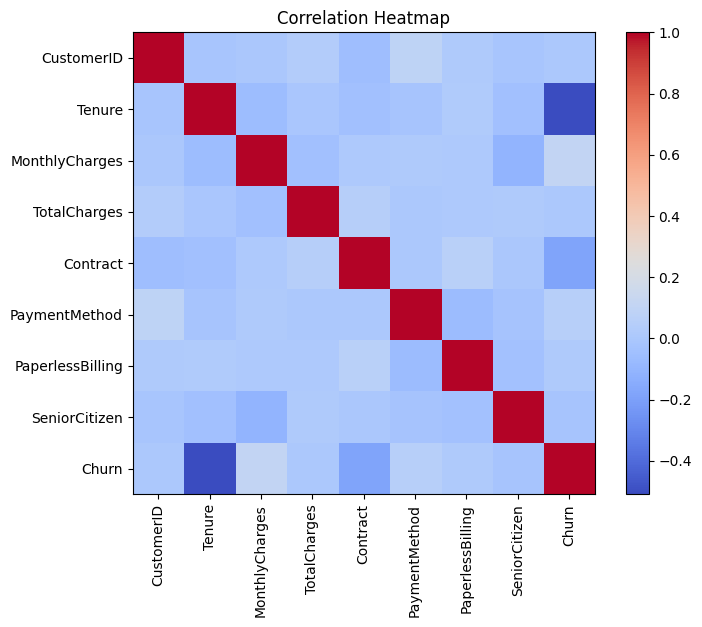

In [25]:
plt.figure(figsize=(8,6))
plt.imshow(df.corr(), cmap='coolwarm', interpolation='nearest')
plt.colorbar()

plt.xticks(range(len(df.columns)), df.columns, rotation=90)
plt.yticks(range(len(df.columns)), df.columns)

plt.title("Correlation Heatmap")

plt.show()

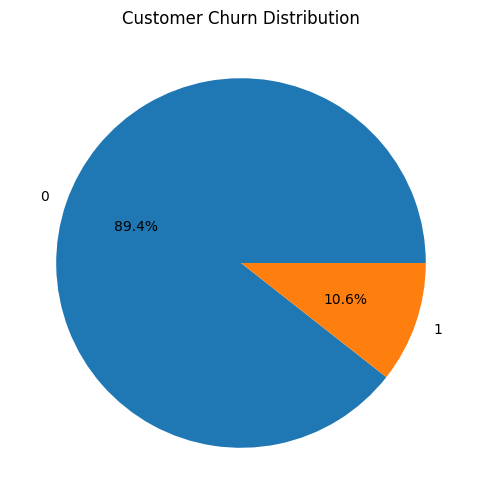

In [26]:
df['Churn'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6)
)

plt.title("Customer Churn Distribution")
plt.ylabel("")
plt.show()

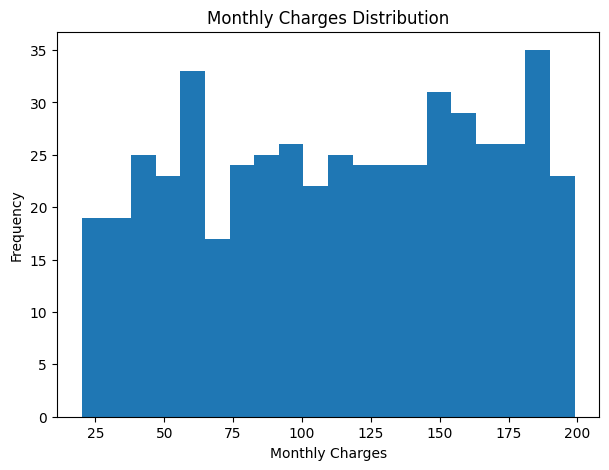

In [27]:
plt.figure(figsize=(7,5))

plt.hist(df['MonthlyCharges'], bins=20)

plt.title("Monthly Charges Distribution")
plt.xlabel("Monthly Charges")
plt.ylabel("Frequency")

plt.show()

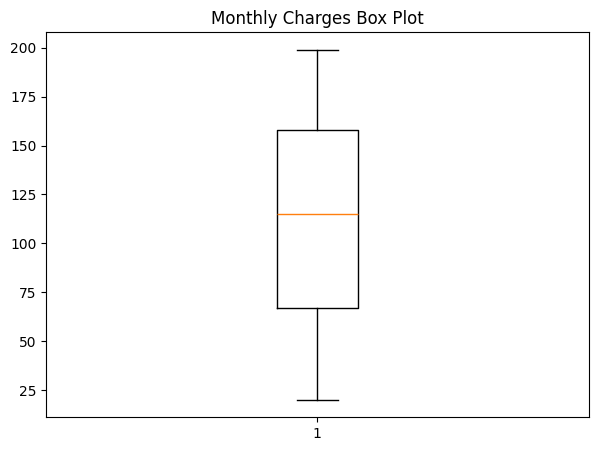

In [28]:
plt.figure(figsize=(7,5))

plt.boxplot(df['MonthlyCharges'])

plt.title("Monthly Charges Box Plot")

plt.show()

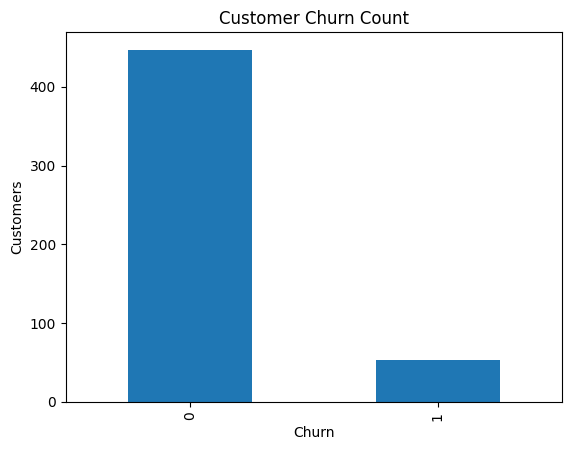

In [29]:
df['Churn'].value_counts().plot(kind='bar')

plt.title("Customer Churn Count")
plt.xlabel("Churn")
plt.ylabel("Customers")

plt.show()

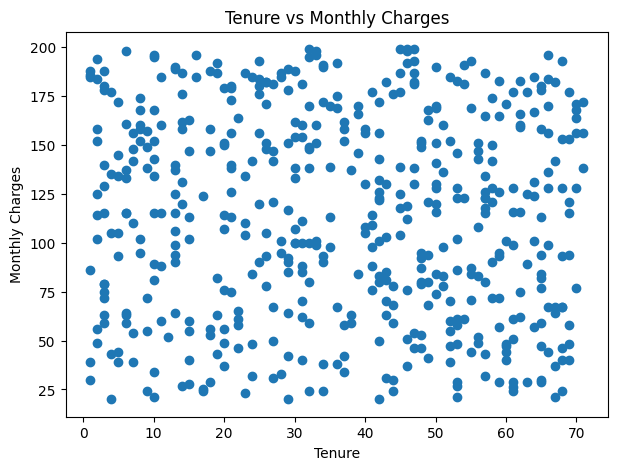

In [30]:
plt.figure(figsize=(7,5))

plt.scatter(df['Tenure'], df['MonthlyCharges'])

plt.xlabel("Tenure")
plt.ylabel("Monthly Charges")

plt.title("Tenure vs Monthly Charges")

plt.show()

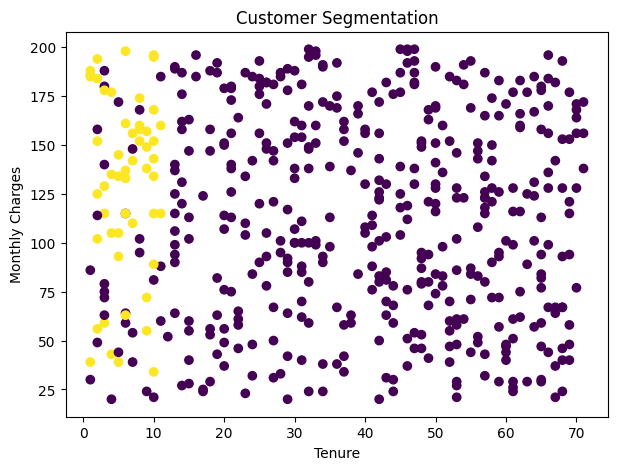

In [31]:
plt.figure(figsize=(7,5))

plt.scatter(
    df['Tenure'],
    df['MonthlyCharges'],
    c=df['Churn']
)

plt.title("Customer Segmentation")

plt.xlabel("Tenure")

plt.ylabel("Monthly Charges")

plt.show()

In [32]:
print(df.groupby("Churn")["MonthlyCharges"].mean())

Churn
0    111.722595
1    129.773585
Name: MonthlyCharges, dtype: float64


In [33]:
print(df.groupby("Churn")["Tenure"].mean())

Churn
0    40.152125
1     6.000000
Name: Tenure, dtype: float64


In [34]:
churn_rate = (df['Churn'].sum()/len(df))*100

print("Churn Rate:", round(churn_rate,2),"%")

Churn Rate: 10.6 %


In [35]:
print("Business Insights")
print("------------------")

print("1. Customers with higher monthly charges tend to churn more.")
print("2. Customers with shorter tenure are more likely to leave.")
print("3. Long-term customers have better retention.")
print("4. Loyalty programs can reduce churn.")
print("5. Personalized offers may improve customer retention.")

Business Insights
------------------
1. Customers with higher monthly charges tend to churn more.
2. Customers with shorter tenure are more likely to leave.
3. Long-term customers have better retention.
4. Loyalty programs can reduce churn.
5. Personalized offers may improve customer retention.


In [36]:
df.to_csv("customer_churn_final.csv", index=False)

In [37]:
from google.colab import files

files.download("customer_churn_final.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>